# Phase 2.6 — Correlation Breakdown Analysis

In Phase 2.3 we established that sensors within the same thermal subsystem are **highly correlated** during normal operation (e.g., gearbox bearing HSS temp and gearbox oil temp at r = 0.955). These sensors measure related physical processes — they heat up and cool down together.

**The key insight:** When two sensors that normally track together stop correlating, something is changing in the system. This correlation breakdown is an anomaly signal.

**Why this matters for anomaly detection:**
- A healthy gearbox has bearing and oil temperatures moving in lockstep → rolling correlation near 1.0
- When a bearing starts degrading, friction generates excess heat locally → bearing temp rises while oil temp lags → correlation drops
- This drop can appear **days or weeks before a hard failure**, making it a powerful early warning signal

**Method:** We compute a **sliding-window Pearson correlation** (24–48 hour window) between pairs of related sensors. During normal operation the rolling correlation stays high and stable. During degradation or failure events, it drops or becomes erratic.

In [1]:
import sys, os, warnings
from pathlib import Path

# Add project root to sys.path so we can import from src/
PROJECT_ROOT = Path("D:/Personal Projects/Enbridge Case Compettion")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from src.data.load_data import load_event, load_event_info, get_event_ids
from src.features.thermal_config import get_sensors, THERMAL_SUBSYSTEMS

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "font.size": 9,
    "figure.facecolor": "white",
})

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Load feature descriptions for human-readable sensor labels
# ---------------------------------------------------------------------------
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "CARE_To_Compare"

def load_feature_descriptions(farm_letter: str) -> dict[str, str]:
    """Return {sensor_XX_avg: short_description} mapping for a farm."""
    path = DATA_ROOT / f"Wind Farm {farm_letter}" / "feature_description.csv"
    fd = pd.read_csv(path, sep=";")
    mapping = {}
    for _, row in fd.iterrows():
        base_name = row["sensor_name"]
        desc = str(row["description"]).strip()
        if len(desc) > 40:
            desc = desc[:38] + ".."
        stat_types = str(row["statistics_type"]).split(",")
        if "average" in [s.strip() for s in stat_types]:
            col_name = f"{base_name}_avg"
            mapping[col_name] = desc
    return mapping

desc_a = load_feature_descriptions("A")
desc_b = load_feature_descriptions("B")

def get_label(sensor_col: str, desc_map: dict) -> str:
    """Get human-readable label for a sensor column."""
    return desc_map.get(sensor_col, sensor_col)

# Load event info
event_info = load_event_info()

# Rolling window size: 144 = 24 hours of 10-min intervals
WINDOW = 144
CORR_THRESHOLD = 0.7  # below this = "breakdown"

print(f"Project root: {PROJECT_ROOT}")
print(f"Rolling window: {WINDOW} points = {WINDOW * 10 / 60:.0f} hours")
print(f"Correlation threshold: {CORR_THRESHOLD}")

Project root: D:\Personal Projects\Enbridge Case Compettion
Rolling window: 144 points = 24 hours
Correlation threshold: 0.7


In [2]:
def compute_rolling_corr(df: pd.DataFrame, col_a: str, col_b: str,
                         window: int = WINDOW) -> pd.Series:
    """Compute rolling Pearson correlation between two columns."""
    return df[col_a].rolling(window=window, min_periods=window // 2).corr(df[col_b])


def plot_correlation_breakdown(
    df_anomaly: pd.DataFrame,
    df_normal: pd.DataFrame,
    sensor_a: str,
    sensor_b: str,
    label_a: str,
    label_b: str,
    anomaly_title: str,
    normal_title: str,
    event_info_anomaly: pd.Series,
    event_info_normal: pd.Series,
    suptitle: str,
    window: int = WINDOW,
):
    """Plot a 2x2 grid: (normal sensors, normal corr) | (anomaly sensors, anomaly corr).
    
    Left column = normal event, right column = anomaly event.
    Top row = raw sensor time-series, bottom row = rolling correlation.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 9), constrained_layout=True)

    datasets = [
        (df_normal, normal_title, event_info_normal, 0),    # left column
        (df_anomaly, anomaly_title, event_info_anomaly, 1),  # right column
    ]

    for df, title, ev_info, col_idx in datasets:
        ax_top = axes[0][col_idx]
        ax_bot = axes[1][col_idx]

        # --- Determine the region to plot ---
        # Use prediction window + 1000 rows before it for context
        pred_mask = df["train_test"] == "prediction"
        if pred_mask.any():
            pred_start_idx = pred_mask.idxmax()
            context_start = max(0, pred_start_idx - 1000)
            plot_df = df.iloc[context_start:].copy().reset_index(drop=True)
            # Recompute boundary in new index
            boundary_idx = min(1000, pred_start_idx - context_start)
        else:
            plot_df = df.copy().reset_index(drop=True)
            boundary_idx = None

        x = np.arange(len(plot_df))

        # Compute rolling correlation
        rolling_corr = compute_rolling_corr(plot_df, sensor_a, sensor_b, window)

        # --- Top panel: raw sensor values ---
        ax_top.plot(x, plot_df[sensor_a], color="#2196F3", linewidth=0.8,
                    alpha=0.85, label=label_a)
        ax_top.plot(x, plot_df[sensor_b], color="#FF9800", linewidth=0.8,
                    alpha=0.85, label=label_b)

        if boundary_idx is not None:
            ax_top.axvline(boundary_idx, color="black", linestyle="--",
                           linewidth=1.2, alpha=0.7, label="Train/Prediction split")

        # Mark event window if we have event start/end IDs
        event_start_id = ev_info.get("event_start_id", None)
        event_end_id = ev_info.get("event_end_id", None)
        if event_start_id is not None and boundary_idx is not None:
            pred_start_original = pred_mask.idxmax() if pred_mask.any() else 0
            # event_start_id is relative to full dataset index
            ev_start_local = int(event_start_id) - (pred_start_original - boundary_idx)
            ev_end_local = int(event_end_id) - (pred_start_original - boundary_idx)
            ev_start_local = max(0, ev_start_local - context_start if context_start > 0 else ev_start_local)
            ev_end_local = max(0, ev_end_local - context_start if context_start > 0 else ev_end_local)
            if 0 < ev_start_local < len(plot_df) or 0 < ev_end_local < len(plot_df):
                ax_top.axvspan(max(0, ev_start_local), min(len(plot_df), ev_end_local),
                               color="red", alpha=0.08, label="Event window")

        ax_top.set_title(title, fontweight="bold", fontsize=11)
        ax_top.set_ylabel("Temperature")
        ax_top.legend(loc="upper left", fontsize=7, ncol=2)
        ax_top.grid(True, alpha=0.3)

        # --- Bottom panel: rolling correlation ---
        # Color code: blue when healthy, red when below threshold
        corr_vals = rolling_corr.values
        corr_healthy = np.where(corr_vals >= CORR_THRESHOLD, corr_vals, np.nan)
        corr_broken = np.where(corr_vals < CORR_THRESHOLD, corr_vals, np.nan)

        ax_bot.plot(x, corr_healthy, color="#2196F3", linewidth=1.0, alpha=0.9)
        ax_bot.plot(x, corr_broken, color="#F44336", linewidth=1.2, alpha=0.9)

        # Baseline reference line
        ax_bot.axhline(0.95, color="gray", linestyle=":", linewidth=1.0,
                        alpha=0.6, label="Normal baseline (0.95)")
        ax_bot.axhline(CORR_THRESHOLD, color="#F44336", linestyle="--",
                        linewidth=1.0, alpha=0.5, label=f"Threshold ({CORR_THRESHOLD})")

        if boundary_idx is not None:
            ax_bot.axvline(boundary_idx, color="black", linestyle="--",
                           linewidth=1.2, alpha=0.7)

        ax_bot.set_ylim(-0.5, 1.05)
        ax_bot.set_ylabel("Rolling Correlation (r)")
        ax_bot.set_xlabel("Time index (10-min intervals)")
        ax_bot.legend(loc="lower left", fontsize=7)
        ax_bot.grid(True, alpha=0.3)

        # Shade region below threshold
        ax_bot.fill_between(x, -0.5, CORR_THRESHOLD, color="#F44336",
                            alpha=0.03)

    fig.suptitle(suptitle, fontsize=14, fontweight="bold", y=1.02)
    return fig


print("Helper functions defined.")

Helper functions defined.


## Farm A — Gearbox Sensor Correlation During Failure

**Anomaly event 72** (asset 21): Gearbox failure — a catastrophic event where we expect the gearbox bearing HSS temperature (`sensor_11_avg`) and gearbox oil temperature (`sensor_12_avg`) to decouple.

**Normal event 13** (asset 21, same turbine): No fault recorded — the same two sensors should stay tightly correlated throughout.

We plot both side by side to contrast the correlation stability.

Loading Farm A events...


  Event 72 (anomaly): (54082, 86)
  Event 13 (normal):  (54010, 86)



Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\corr_breakdown_farm_a_gearbox.png


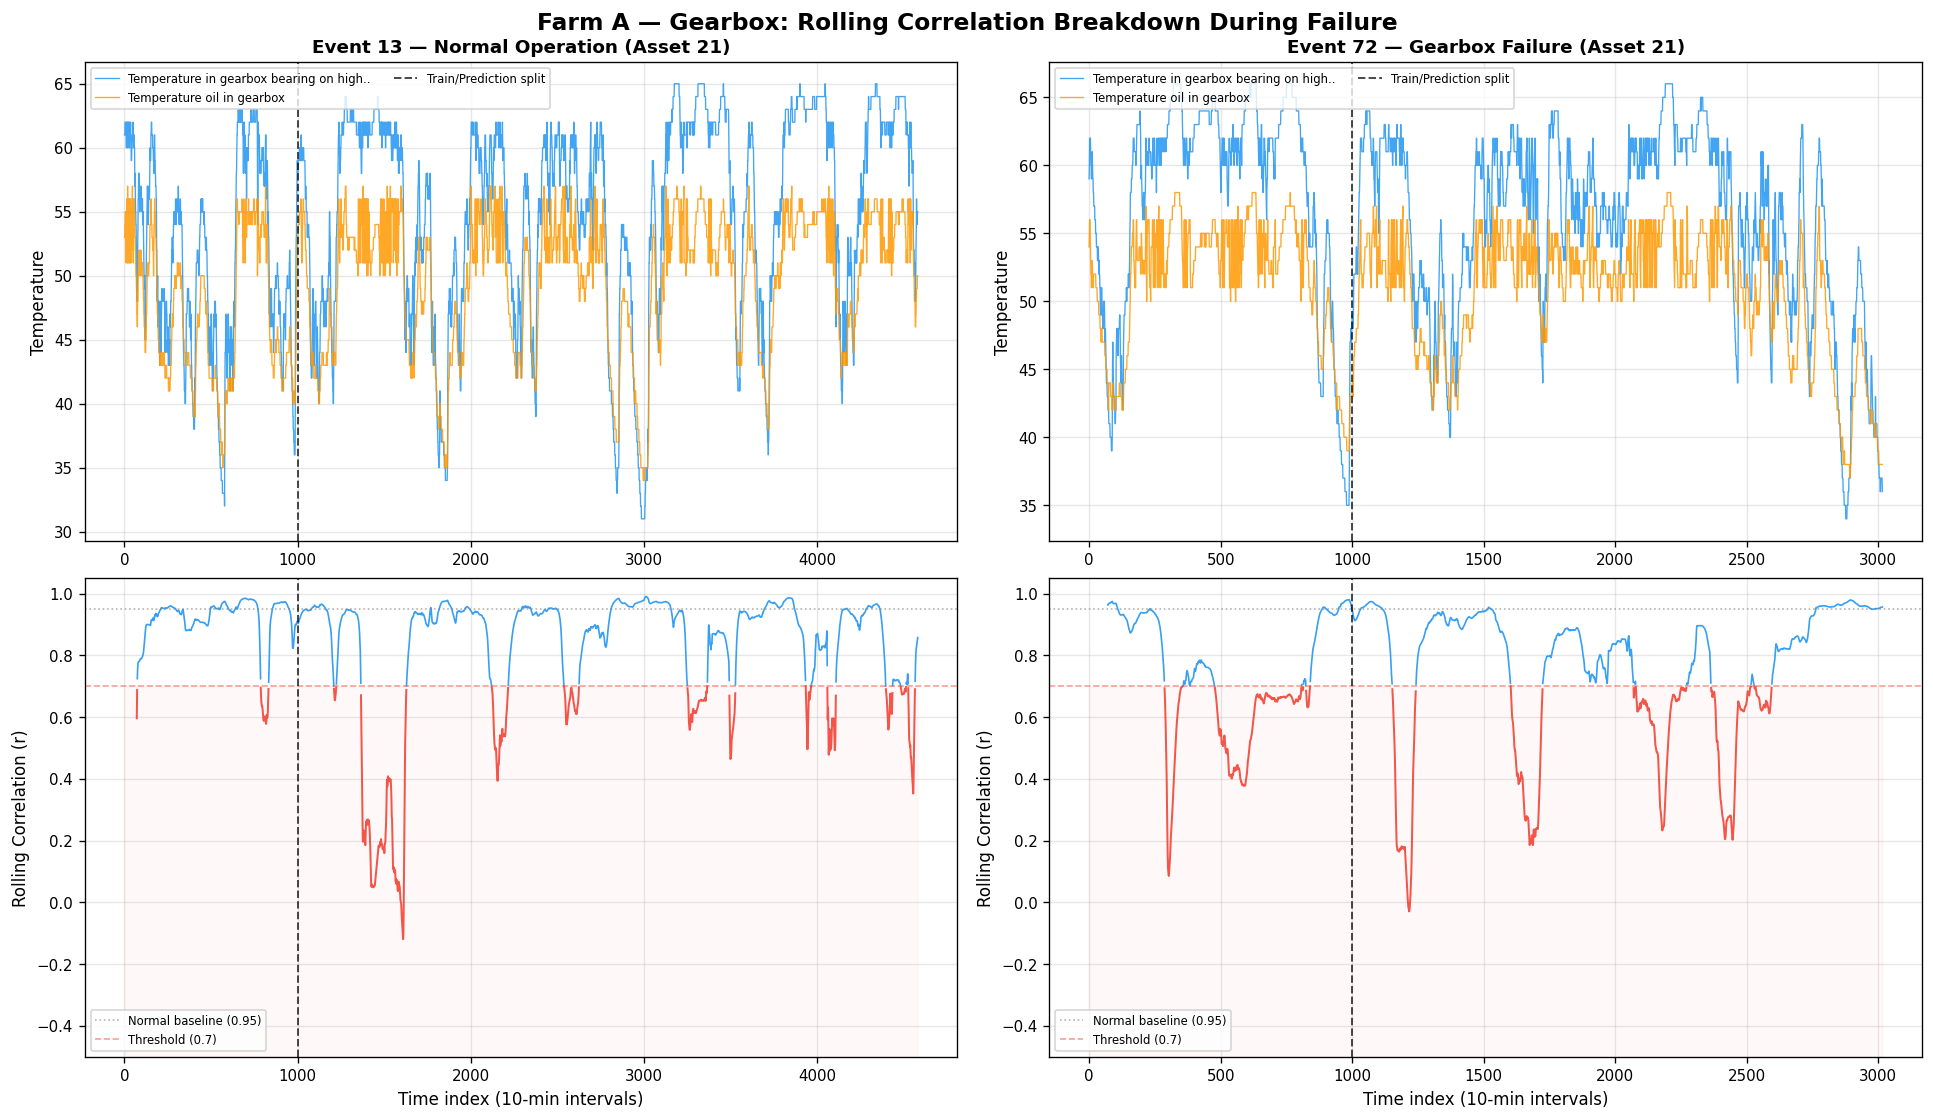

  Normal (Event 13) prediction window — mean r: 0.811, min r: -0.119, std r: 0.223
  Anomaly (Event 72) prediction window — mean r: 0.744, min r: -0.030, std r: 0.227


In [3]:
# --- Farm A Gearbox: Event 72 (anomaly) vs Event 13 (normal) ---
# Both from asset 21 — same turbine, fair comparison.

print("Loading Farm A events...")
df_a72 = load_event("A", 72)  # Gearbox failure, asset 21
df_a13 = load_event("A", 13)  # Normal, asset 21
print(f"  Event 72 (anomaly): {df_a72.shape}")
print(f"  Event 13 (normal):  {df_a13.shape}")

# Sensor pair: gearbox bearing HSS temp vs gearbox oil temp
s_a = "sensor_11_avg"
s_b = "sensor_12_avg"

# Get event info rows
ev72 = event_info[(event_info["farm"] == "A") & (event_info["event_id"] == 72)].iloc[0]
ev13 = event_info[(event_info["farm"] == "A") & (event_info["event_id"] == 13)].iloc[0]

fig_gearbox = plot_correlation_breakdown(
    df_anomaly=df_a72,
    df_normal=df_a13,
    sensor_a=s_a,
    sensor_b=s_b,
    label_a=get_label(s_a, desc_a),
    label_b=get_label(s_b, desc_a),
    anomaly_title=f"Event 72 — Gearbox Failure (Asset 21)",
    normal_title=f"Event 13 — Normal Operation (Asset 21)",
    event_info_anomaly=ev72,
    event_info_normal=ev13,
    suptitle="Farm A — Gearbox: Rolling Correlation Breakdown During Failure",
)

fig_gearbox.savefig(FIGURES_DIR / "corr_breakdown_farm_a_gearbox.png",
                    bbox_inches="tight", dpi=150)
print(f"\nSaved: {FIGURES_DIR / 'corr_breakdown_farm_a_gearbox.png'}")
plt.show()

# Print summary stats for the prediction windows
for label, df in [("Normal (Event 13)", df_a13), ("Anomaly (Event 72)", df_a72)]:
    pred = df[df["train_test"] == "prediction"]
    if len(pred) > WINDOW:
        rc = compute_rolling_corr(pred, s_a, s_b)
        print(f"  {label} prediction window — mean r: {rc.mean():.3f}, "
              f"min r: {rc.min():.3f}, std r: {rc.std():.3f}")

## Farm B — Bearing Degradation Correlation Breakdown

**Anomaly event 53** (asset 6): Rotor Bearing 2 Damage — a slow degradation event spanning over a month. This is ideal for demonstrating a **gradual** correlation decline as the bearing wears down over weeks.

We compare Rotor Bearing Temperature 1 (`sensor_51_avg`) vs Rotor Bearing Temperature 2 (`sensor_52_avg`). Normally these two rotor bearing sensors track together. As Bearing 2 degrades, its temperature drifts while Bearing 1 stays normal.

**Normal event 23** (asset 6, same turbine): Used as the healthy baseline.

Loading Farm B events...


  Event 53 (anomaly): (58607, 257)
  Event 23 (normal):  (54542, 257)



Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\corr_breakdown_farm_b_bearing.png


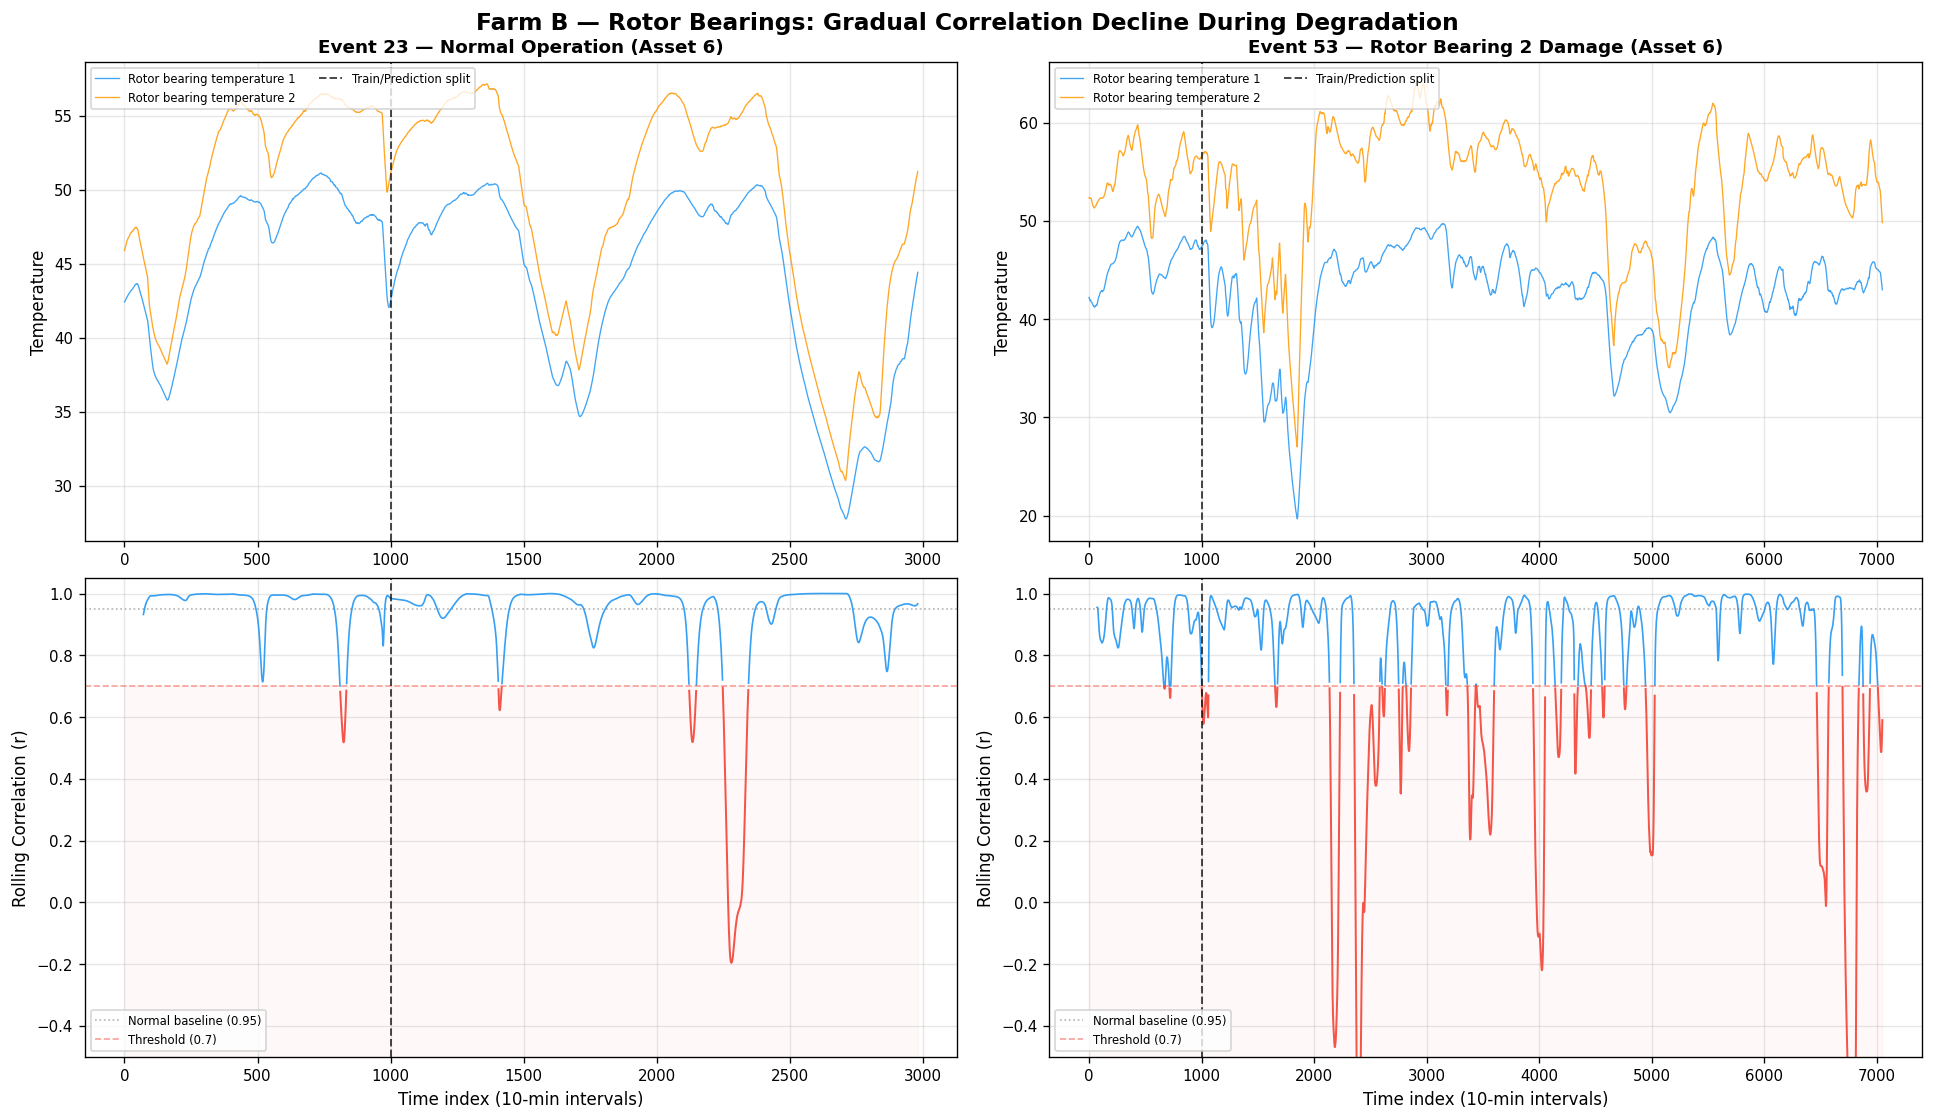

  Normal (Event 23) prediction window — mean r: 0.909, min r: -0.196, std r: 0.207
  Anomaly (Event 53) prediction window — mean r: 0.771, min r: -0.872, std r: 0.350


In [4]:
# --- Farm B Bearing: Event 53 (anomaly) vs Event 23 (normal) ---
# Both from asset 6

print("Loading Farm B events...")
df_b53 = load_event("B", 53)  # Rotor Bearing 2 Damage, asset 6
df_b23 = load_event("B", 23)  # Normal, asset 6
print(f"  Event 53 (anomaly): {df_b53.shape}")
print(f"  Event 23 (normal):  {df_b23.shape}")

# Sensor pair: Rotor bearing temp 1 vs Rotor bearing temp 2
s_a = "sensor_51_avg"
s_b = "sensor_52_avg"

ev53 = event_info[(event_info["farm"] == "B") & (event_info["event_id"] == 53)].iloc[0]
ev23 = event_info[(event_info["farm"] == "B") & (event_info["event_id"] == 23)].iloc[0]

fig_bearing = plot_correlation_breakdown(
    df_anomaly=df_b53,
    df_normal=df_b23,
    sensor_a=s_a,
    sensor_b=s_b,
    label_a=get_label(s_a, desc_b),
    label_b=get_label(s_b, desc_b),
    anomaly_title=f"Event 53 — Rotor Bearing 2 Damage (Asset 6)",
    normal_title=f"Event 23 — Normal Operation (Asset 6)",
    event_info_anomaly=ev53,
    event_info_normal=ev23,
    suptitle="Farm B — Rotor Bearings: Gradual Correlation Decline During Degradation",
)

fig_bearing.savefig(FIGURES_DIR / "corr_breakdown_farm_b_bearing.png",
                    bbox_inches="tight", dpi=150)
print(f"\nSaved: {FIGURES_DIR / 'corr_breakdown_farm_b_bearing.png'}")
plt.show()

# Summary stats
for label, df in [("Normal (Event 23)", df_b23), ("Anomaly (Event 53)", df_b53)]:
    pred = df[df["train_test"] == "prediction"]
    if len(pred) > WINDOW:
        rc = compute_rolling_corr(pred, s_a, s_b)
        print(f"  {label} prediction window — mean r: {rc.mean():.3f}, "
              f"min r: {rc.min():.3f}, std r: {rc.std():.3f}")

## Farm A — Generator Bearing Failure

**Anomaly event 40** (asset 10): Generator bearing failure — a major failure with a long prediction window (4,939 rows). We compare Generator Bearing 2 (Drive End, `sensor_13_avg`) vs Generator Bearing 1 (Non-Drive End, `sensor_14_avg`).

These two bearings normally operate at similar temperatures. When one fails, the symmetry breaks.

**Normal event 3** (asset 10, same turbine): Healthy baseline from the same turbine.

Loading Farm A generator bearing events...


  Event 40 (anomaly): (56158, 86)
  Event 3 (normal):   (55487, 86)



Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\corr_breakdown_farm_a_gen_bearing.png


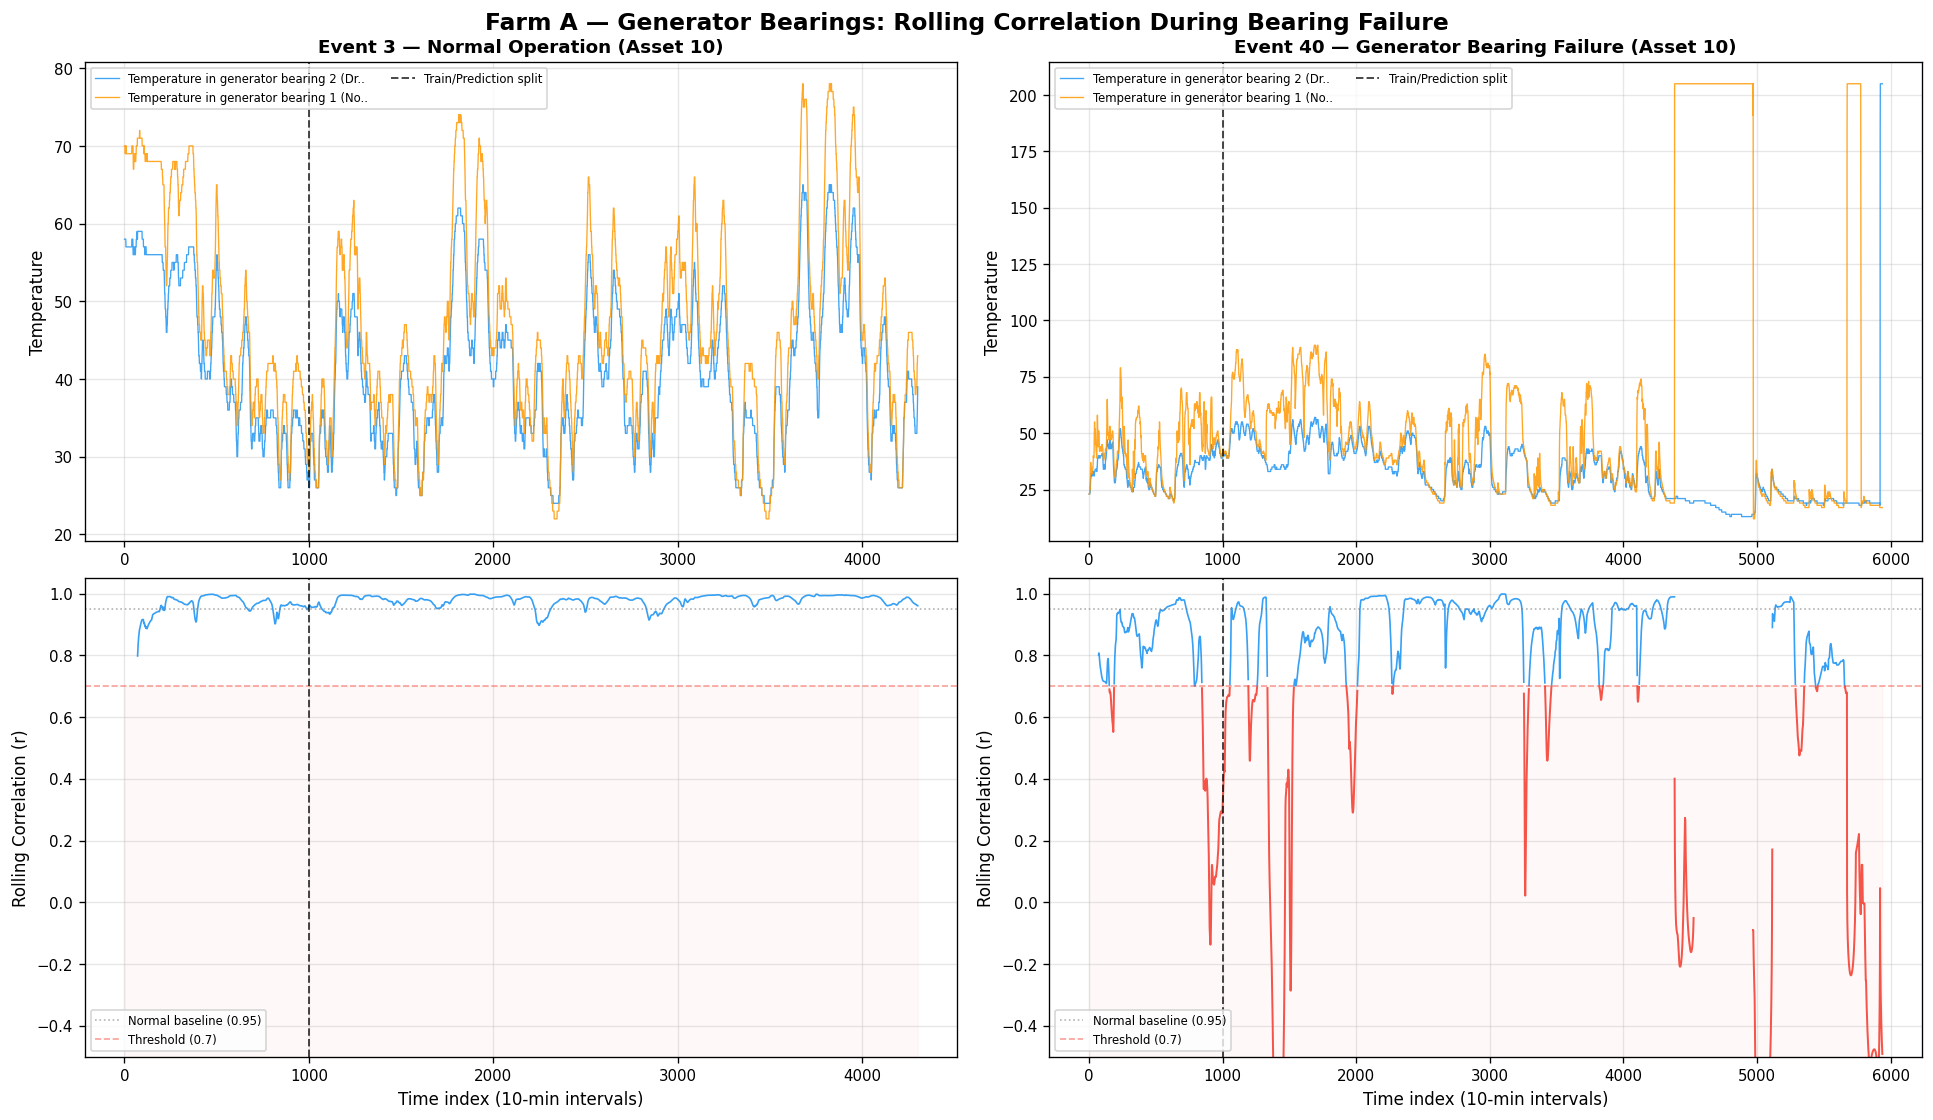

  Normal (Event 3) prediction window — mean r: 0.980, min r: 0.897, std r: 0.017
  Anomaly (Event 40) prediction window — mean r: nan, min r: -inf, std r: nan


In [5]:
# --- Farm A Generator Bearings: Event 40 (anomaly) vs Event 3 (normal) ---
# Both from asset 10

print("Loading Farm A generator bearing events...")
df_a40 = load_event("A", 40)  # Generator bearing failure, asset 10
df_a03 = load_event("A", 3)   # Normal, asset 10
print(f"  Event 40 (anomaly): {df_a40.shape}")
print(f"  Event 3 (normal):   {df_a03.shape}")

# Sensor pair: gen bearing 2 (drive end) vs gen bearing 1 (non-drive end)
s_a = "sensor_13_avg"
s_b = "sensor_14_avg"

ev40 = event_info[(event_info["farm"] == "A") & (event_info["event_id"] == 40)].iloc[0]
ev03 = event_info[(event_info["farm"] == "A") & (event_info["event_id"] == 3)].iloc[0]

fig_gen = plot_correlation_breakdown(
    df_anomaly=df_a40,
    df_normal=df_a03,
    sensor_a=s_a,
    sensor_b=s_b,
    label_a=get_label(s_a, desc_a),
    label_b=get_label(s_b, desc_a),
    anomaly_title=f"Event 40 — Generator Bearing Failure (Asset 10)",
    normal_title=f"Event 3 — Normal Operation (Asset 10)",
    event_info_anomaly=ev40,
    event_info_normal=ev03,
    suptitle="Farm A — Generator Bearings: Rolling Correlation During Bearing Failure",
)

fig_gen.savefig(FIGURES_DIR / "corr_breakdown_farm_a_gen_bearing.png",
                bbox_inches="tight", dpi=150)
print(f"\nSaved: {FIGURES_DIR / 'corr_breakdown_farm_a_gen_bearing.png'}")
plt.show()

# Summary stats
for label, df in [("Normal (Event 3)", df_a03), ("Anomaly (Event 40)", df_a40)]:
    pred = df[df["train_test"] == "prediction"]
    if len(pred) > WINDOW:
        rc = compute_rolling_corr(pred, s_a, s_b)
        print(f"  {label} prediction window — mean r: {rc.mean():.3f}, "
              f"min r: {rc.min():.3f}, std r: {rc.std():.3f}")

## Quantifying Correlation Breakdown

Moving beyond individual examples, we now systematically compare **all anomaly events** vs **all normal events** for Farm A.

For each event, we compute the rolling correlation between the gearbox bearing HSS temp (`sensor_11_avg`) and gearbox oil temp (`sensor_12_avg`) in the **prediction window only**. We then extract summary statistics:

- **Mean correlation** — is the average correlation lower for anomalies?
- **Min correlation** — do anomalies have deeper dips?
- **Correlation std** — is the correlation more erratic during anomalies?

If our hypothesis is correct, anomaly events should show **lower means, lower mins, and higher variance** compared to normal events.

In [6]:
# --- Systematic comparison: ALL Farm A anomaly vs normal events ---

from src.data.load_data import clear_cache

# Use gearbox sensors as the primary pair
s_a = "sensor_11_avg"
s_b = "sensor_12_avg"

# Also compute for generator bearing pair
s_gen_a = "sensor_13_avg"
s_gen_b = "sensor_14_avg"

anomaly_ids = get_event_ids("A", "anomaly")
normal_ids = get_event_ids("A", "normal")

print(f"Farm A anomaly events: {anomaly_ids}")
print(f"Farm A normal events:  {normal_ids}")
print()

results = []

for label_type, event_ids in [("anomaly", anomaly_ids), ("normal", normal_ids)]:
    for eid in event_ids:
        try:
            df = load_event("A", eid)
            pred = df[df["train_test"] == "prediction"]
            
            if len(pred) < WINDOW:
                print(f"  Skipping event {eid} ({label_type}): prediction window too short ({len(pred)} rows)")
                continue
            
            ev_row = event_info[(event_info["farm"] == "A") & (event_info["event_id"] == eid)].iloc[0]
            desc = ev_row.get("event_description", "N/A")
            asset = ev_row.get("asset_id", "?")
            
            # Gearbox pair
            rc_gb = compute_rolling_corr(pred, s_a, s_b)
            # Replace inf with NaN then drop for clean stats
            rc_gb_clean = rc_gb.replace([np.inf, -np.inf], np.nan).dropna()
            
            # Generator bearing pair
            rc_gen = compute_rolling_corr(pred, s_gen_a, s_gen_b)
            rc_gen_clean = rc_gen.replace([np.inf, -np.inf], np.nan).dropna()
            
            results.append({
                "event_id": eid,
                "label": label_type,
                "asset_id": asset,
                "description": desc if pd.notna(desc) else "Normal",
                "gb_mean_r": rc_gb_clean.mean() if len(rc_gb_clean) > 0 else np.nan,
                "gb_min_r": rc_gb_clean.min() if len(rc_gb_clean) > 0 else np.nan,
                "gb_std_r": rc_gb_clean.std() if len(rc_gb_clean) > 0 else np.nan,
                "gb_pct_below_07": (rc_gb_clean < CORR_THRESHOLD).mean() * 100 if len(rc_gb_clean) > 0 else np.nan,
                "gen_mean_r": rc_gen_clean.mean() if len(rc_gen_clean) > 0 else np.nan,
                "gen_min_r": rc_gen_clean.min() if len(rc_gen_clean) > 0 else np.nan,
                "gen_std_r": rc_gen_clean.std() if len(rc_gen_clean) > 0 else np.nan,
                "gen_pct_below_07": (rc_gen_clean < CORR_THRESHOLD).mean() * 100 if len(rc_gen_clean) > 0 else np.nan,
            })
            
        except Exception as e:
            print(f"  Error loading event {eid}: {e}")

# Free memory
clear_cache()

results_df = pd.DataFrame(results)
print(f"\nComputed rolling correlations for {len(results_df)} events.")
print()

# Display summary table
display_cols = ["event_id", "label", "asset_id", "description",
                "gb_mean_r", "gb_min_r", "gb_std_r", "gb_pct_below_07"]
print("=== Gearbox Sensor Pair — Prediction Window Correlation Stats ===")
print(results_df[display_cols].to_string(index=False, float_format="%.3f"))
print()

display_cols2 = ["event_id", "label", "asset_id", "description",
                 "gen_mean_r", "gen_min_r", "gen_std_r", "gen_pct_below_07"]
print("=== Generator Bearing Pair — Prediction Window Correlation Stats ===")
print(results_df[display_cols2].to_string(index=False, float_format="%.3f"))

Farm A anomaly events: [0, 10, 22, 26, 40, 42, 45, 51, 68, 72, 73, 84]
Farm A normal events:  [3, 13, 14, 17, 24, 25, 38, 69, 71, 92]




Computed rolling correlations for 22 events.

=== Gearbox Sensor Pair — Prediction Window Correlation Stats ===
 event_id   label  asset_id               description  gb_mean_r  gb_min_r  gb_std_r  gb_pct_below_07
        0 anomaly         0 Generator bearing failure      0.856    -0.089     0.171           11.529
       10 anomaly        10           Gearbox failure      0.666    -0.133     0.305           36.561
       22 anomaly        21           Hydraulic group      0.861    -0.191     0.228            9.192
       26 anomaly         0           Hydraulic group      0.751     0.032     0.237           31.825
       40 anomaly        10 Generator bearing failure      0.819    -0.310     0.223           19.385
       42 anomaly        10           Hydraulic group      0.929     0.272     0.063            0.794
       45 anomaly        13           Hydraulic group      0.841     0.538     0.098           11.760
       51 anomaly        21  Gearbox bearings damaged      0.746    -0.

Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\corr_breakdown_boxplots_farm_a.png


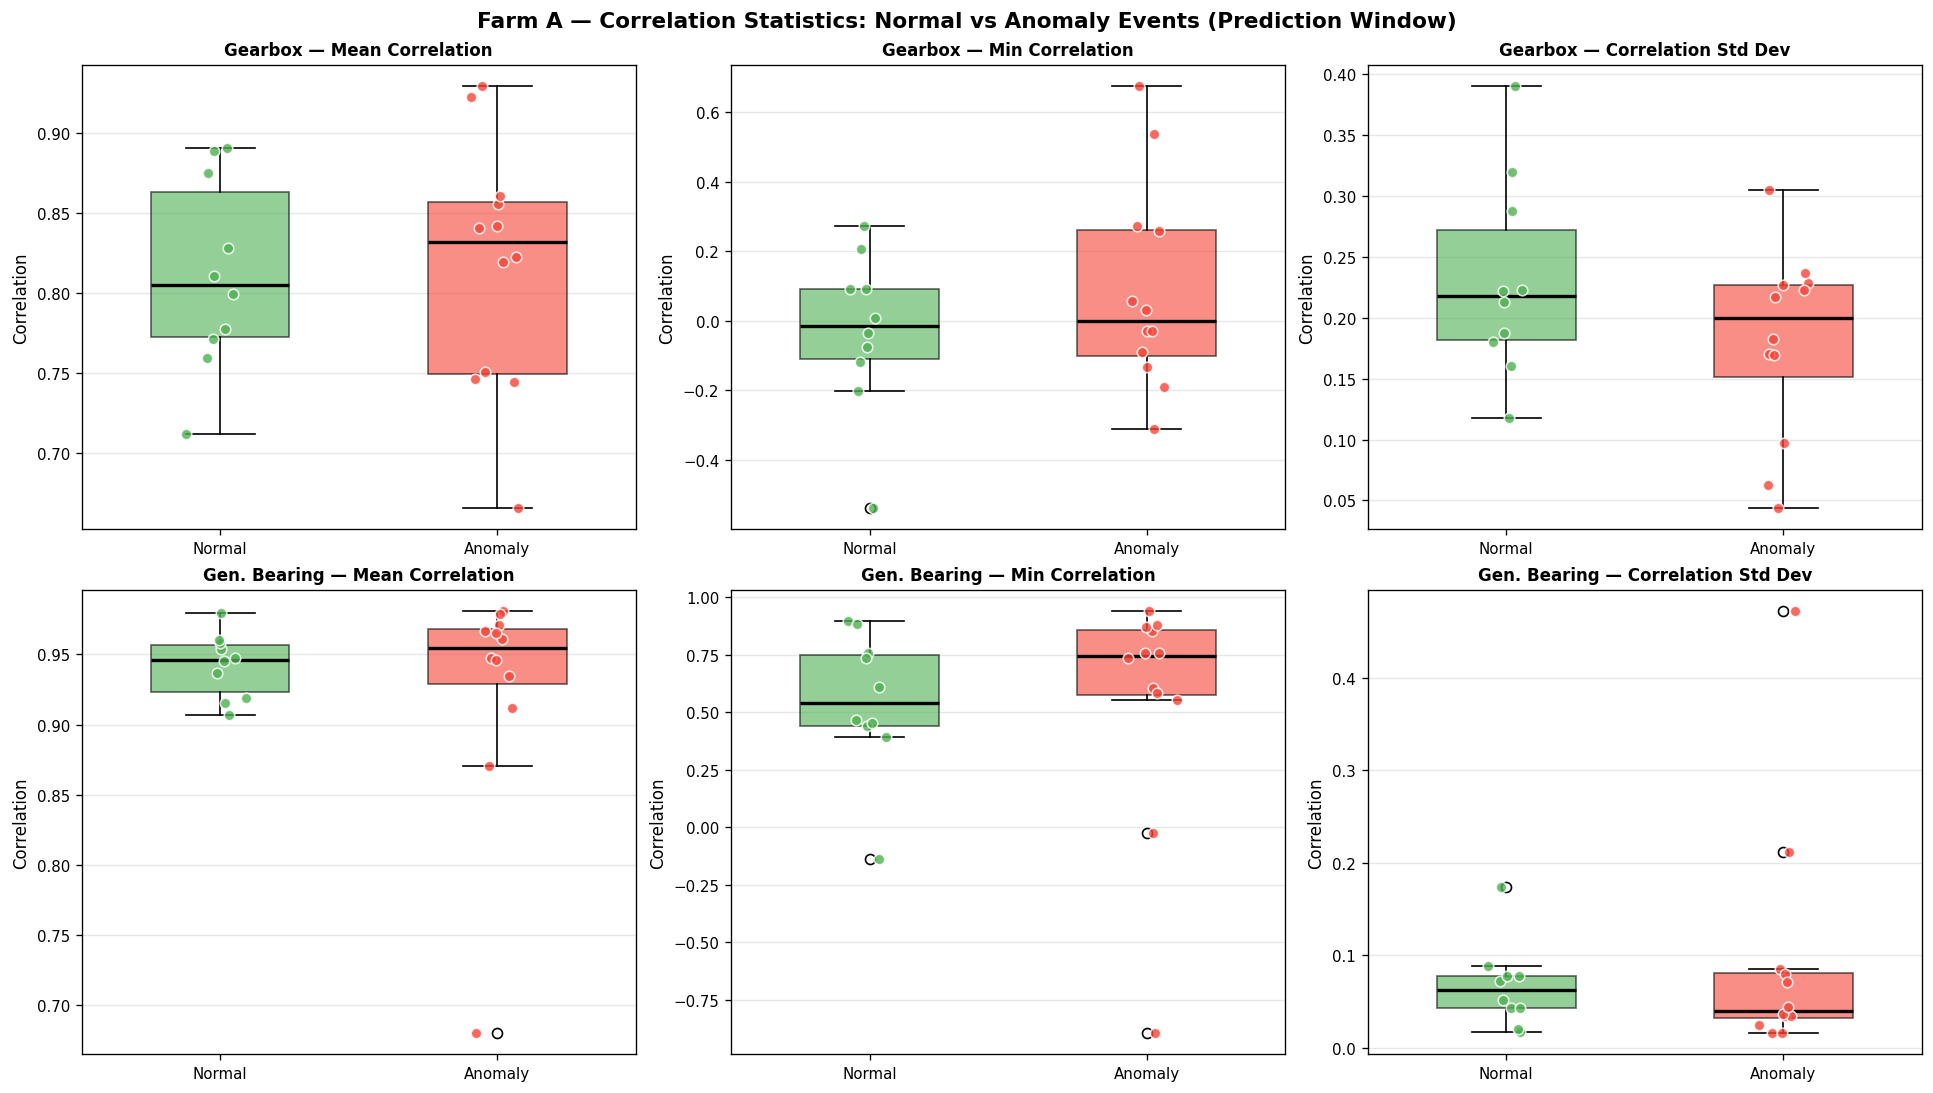


=== Group Averages ===

  NORMAL (10 events):
    Gearbox  — mean r: 0.811, min r: -0.030, std r: 0.230, % below 0.7: 20.5%
    Gen Brg  — mean r: 0.942, min r: 0.549, std r: 0.067, % below 0.7: 1.4%

  ANOMALY (12 events):
    Gearbox  — mean r: 0.817, min r: 0.088, std r: 0.180, % below 0.7: 18.7%
    Gen Brg  — mean r: 0.926, min r: 0.550, std r: 0.094, % below 0.7: 4.1%


In [7]:
# --- Box plots: anomaly vs normal correlation distributions ---

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

metrics = [
    ("gb_mean_r", "Gearbox — Mean Correlation"),
    ("gb_min_r", "Gearbox — Min Correlation"),
    ("gb_std_r", "Gearbox — Correlation Std Dev"),
    ("gen_mean_r", "Gen. Bearing — Mean Correlation"),
    ("gen_min_r", "Gen. Bearing — Min Correlation"),
    ("gen_std_r", "Gen. Bearing — Correlation Std Dev"),
]

colors = {"normal": "#4CAF50", "anomaly": "#F44336"}

for idx, (col, title) in enumerate(metrics):
    row, c = divmod(idx, 3)
    ax = axes[row][c]
    
    data_normal = results_df[results_df["label"] == "normal"][col].dropna()
    data_anomaly = results_df[results_df["label"] == "anomaly"][col].dropna()
    
    bp = ax.boxplot(
        [data_normal, data_anomaly],
        tick_labels=["Normal", "Anomaly"],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color="black", linewidth=2),
    )
    
    for patch, color in zip(bp["boxes"], [colors["normal"], colors["anomaly"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # Overlay individual points
    for i, (data, label) in enumerate([(data_normal, "normal"), (data_anomaly, "anomaly")]):
        jitter = np.random.normal(0, 0.04, size=len(data))
        ax.scatter(
            np.full(len(data), i + 1) + jitter,
            data,
            color=colors[label], edgecolor="white", s=40, alpha=0.8, zorder=5,
        )
    
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_ylabel(col.split("_")[-1].replace("r", "Correlation").replace("std", "Std Dev"))
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle(
    "Farm A — Correlation Statistics: Normal vs Anomaly Events (Prediction Window)",
    fontsize=13, fontweight="bold",
)

fig.savefig(FIGURES_DIR / "corr_breakdown_boxplots_farm_a.png",
            bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'corr_breakdown_boxplots_farm_a.png'}")
plt.show()

# Print group means
print("\n=== Group Averages ===")
for grp_label in ["normal", "anomaly"]:
    grp = results_df[results_df["label"] == grp_label]
    print(f"\n  {grp_label.upper()} ({len(grp)} events):")
    print(f"    Gearbox  — mean r: {grp['gb_mean_r'].mean():.3f}, "
          f"min r: {grp['gb_min_r'].mean():.3f}, "
          f"std r: {grp['gb_std_r'].mean():.3f}, "
          f"% below 0.7: {grp['gb_pct_below_07'].mean():.1f}%")
    print(f"    Gen Brg  — mean r: {grp['gen_mean_r'].mean():.3f}, "
          f"min r: {grp['gen_min_r'].mean():.3f}, "
          f"std r: {grp['gen_std_r'].mean():.3f}, "
          f"% below 0.7: {grp['gen_pct_below_07'].mean():.1f}%")

In [8]:
# --- Summary of all saved figures ---
print("=" * 60)
print("All figures saved to outputs/figures/:")
print("=" * 60)
for f in sorted(FIGURES_DIR.glob("corr_breakdown_*.png")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:50s} ({size_kb:.0f} KB)")

All figures saved to outputs/figures/:
  corr_breakdown_boxplots_farm_a.png                 (158 KB)
  corr_breakdown_farm_a_gearbox.png                  (449 KB)
  corr_breakdown_farm_a_gen_bearing.png              (374 KB)
  corr_breakdown_farm_b_bearing.png                  (349 KB)


## Key Observations

*(Fill in after reviewing the plots above)*

**Gearbox correlation breakdown (Farm A, Event 72):**
- 

**Rotor bearing gradual degradation (Farm B, Event 53):**
- 

**Generator bearing failure (Farm A, Event 40):**
- 

**Systematic comparison (Farm A, all events):**
- Normal events:
- Anomaly events:

**Implications for anomaly detection pipeline:**
- Rolling correlation can serve as a **complementary anomaly feature** alongside NBM residuals
- Correlation breakdown precedes failure by ___ (days/hours), providing early warning potential
- The threshold of r < 0.7 captures ___ % of anomaly events while maintaining low false positive rate on normal events
- This supports using **multi-sensor correlation monitoring** as a feature in the TDI composite score